# 1. Introduction

This notebook performs an exploratory data analysis of the **EM-DAT Public dataset** downloaded from the entire period of 1900-2026. The goal is to understand the structure of the data, identify the most relevant columns for visualization, and build a small set of clear exploratory charts.

According to the [official EM-DAT documentation](https://doc.emdat.be/docs/):

- The **EM-DAT Public dataset** was designed in 1988 and considers disasters to be events involving an unexpected and overwhelming harmful impact on human beings. It records both natural and technological disasters that meet the [EM-DAT inclusion criteria](https://doc.emdat.be/docs/protocols/entry-criteria/).
- Each row has a unique identifier `DisNo.`, which combines the disaster sequence and the ISO country code. As a result, each row represents **one disaster impact in one country**.

# 2. Data Overview

The first step is to preview the data, confirm the size of the table and inspect the column names and their data types.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Define data path and sheet name
DATA_PATH = Path("../../data/public_emdat_incl_hist_2026-03-17.xlsx").resolve()
SHEET_NAME = "EM-DAT Data"

# Load the dataset
df = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)

# Preview first 5 rows
df.head(5)

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,1900-0003-USA,Yes,nat-met-sto-tro,Natural,Meteorological,Storm,Tropical cyclone,NaN,NaN,USA,...,NaN,NaN,NaN,30000.0,1131126.0,2.652223,NaN,NaN,2004-10-18,2023-10-17
1,1900-0005-USA,Yes,tec-ind-fir-fir,Technological,Industrial accident,Fire (Industrial),Fire (Industrial),NaN,NaN,USA,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
2,1900-0006-JAM,Yes,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
3,1900-0007-JAM,Yes,nat-bio-epi-vir,Natural,Biological,Epidemic,Viral disease,NaN,Gastroenteritis,JAM,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25
4,1900-0008-JPN,Yes,nat-geo-vol-ash,Natural,Geophysical,Volcanic activity,Ash fall,NaN,NaN,JPN,...,NaN,NaN,NaN,NaN,NaN,2.652223,NaN,NaN,2003-07-01,2023-09-25


In [2]:
print(df.shape)

(27532, 47)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27532 entries, 0 to 27531
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   DisNo.                                     27532 non-null  object 
 1   Historic                                   27532 non-null  object 
 2   Classification Key                         27532 non-null  object 
 3   Disaster Group                             27532 non-null  object 
 4   Disaster Subgroup                          27532 non-null  object 
 5   Disaster Type                              27532 non-null  object 
 6   Disaster Subtype                           27532 non-null  object 
 7   External IDs                               4685 non-null   object 
 8   Event Name                                 8726 non-null   object 
 9   ISO                                        27532 non-null  object 
 10  Country               

# 3. Data Quality Assessment

In this section, we will assess the quality of the data and prepare it for visualization. This includes checking for duplicate rows, and checking for missing values and identifying the columns of interest.

Cleaning decisions used here:

- Remove deprecated columns according to the documentation: `OFDA/BHA Response`, `AID Contribution ('000 US$)`, `Admin Units`
- Keep time, geography, categories, impacts, adjusted economic variables, magnitude, and event labels
- Ignore metadata such as classification keys, external IDs, origin, associated types, river basins, CPI, and GADM admin geometry fields

In [4]:
# List of columns of interest 
selected_columns = [
    "DisNo.",
    "Historic",
    "Event Name",
    "ISO",
    "Country",
    "Subregion",
    "Region",
    "Latitude",
    "Longitude",
    "Disaster Group",
    "Disaster Subgroup",
    "Disaster Type",
    "Disaster Subtype",
    "Magnitude",
    "Magnitude Scale",
    "Start Year",
    "Start Month",
    "Start Day",
    "End Year",
    "End Month",
    "End Day",
    "Total Deaths",
    "No. Injured",
    "No. Affected",
    "No. Homeless",
    "Total Affected",
    "Reconstruction Costs, Adjusted ('000 US$)",
    "Insured Damage, Adjusted ('000 US$)",
    "Total Damage, Adjusted ('000 US$)",
]

# Add a Disaster_ID column that captures the unique disaster event across multiple countries.
df_clean = df.copy()
df_clean["Disaster_ID"] = df_clean["DisNo."].str.split("-").str[:2].str.join("-")

# Keep only the columns of interest for analysis and visualization.
df_clean = df_clean[selected_columns + ["Disaster_ID"]].copy()

# Check missing values after selecting the columns of interest.
missing_summary = (
    df_clean.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_values")
    .to_frame()
)
missing_summary["missing_pct"] = (missing_summary["missing_values"] / len(df_clean) * 100).round(2)
missing_summary = missing_summary[missing_summary["missing_values"] > 0]

# Check duplicate rows in the cleaned dataframe.
duplicate_count = df_clean.duplicated().sum()

print(f"Cleaned dataframe shape: {df_clean.shape}")
print(f"Duplicate rows in df_clean: {duplicate_count}")
print()
print("Missing values summary:")
display(missing_summary)

Cleaned dataframe shape: (27532, 30)
Duplicate rows in df_clean: 0

Missing values summary:


,missing_values,missing_pct
"Reconstruction Costs, Adjusted ('000 US$)",27490,99.85
"Insured Damage, Adjusted ('000 US$)",26390,95.85
No. Homeless,24811,90.12
Latitude,24699,89.71
Longitude,24699,89.71
Magnitude,22235,80.76
"Total Damage, Adjusted ('000 US$)",21638,78.59
Event Name,18806,68.31
No. Injured,18387,66.78
No. Affected,15943,57.91


In [5]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,2833.0,1.872076e+01,2.162862e+01,-72.640,3.295,23.200,36.739,6.793000e+01
Longitude,2833.0,3.971825e+01,7.733335e+01,-178.252,-0.100,49.414,102.827,1.796500e+02
Magnitude,5297.0,4.572735e+04,6.011830e+05,-57.000,6.900,145.000,5280.000,4.000000e+07
Start Year,27532.0,1.999912e+03,1.984978e+01,1900.000,1992.000,2003.000,2013.000,2.026000e+03
Start Month,27050.0,6.489612e+00,3.418787e+00,1.000,4.000,7.000,9.000,1.200000e+01
Start Day,23575.0,1.538057e+01,8.916317e+00,1.000,8.000,15.000,23.000,3.100000e+01
End Year,27532.0,1.999946e+03,1.984188e+01,1900.000,1992.000,2003.000,2013.000,2.026000e+03
End Month,26757.0,6.590986e+00,3.399277e+00,1.000,4.000,7.000,9.000,1.200000e+01
End Day,23686.0,1.576138e+01,8.876664e+00,1.000,8.000,16.000,23.750,3.100000e+01
Total Deaths,21981.0,1.510442e+03,4.945595e+04,1.000,10.000,20.000,48.000,3.700000e+06


# 4. Exploratory Analysis


## Disaster group

This pie chart below shows how the total number of unique disasters is distributed across disaster groups. The counts are based on unique `Disaster_ID` values, so one disaster affecting multiple countries is counted only once.

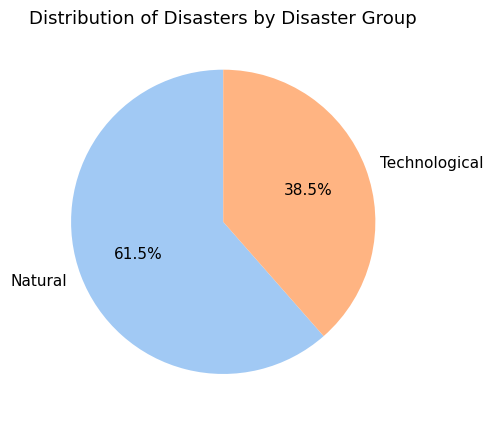

In [6]:
# Count unique disasters by disaster group.
disaster_group_counts = (
    df_clean.groupby("Disaster Group")["Disaster_ID"]
    .nunique()
    .sort_values(ascending=False)
)

# Plot the distribution of unique disasters across disaster groups.
pastel_colors = sns.color_palette("pastel", n_colors=len(disaster_group_counts))
plt.figure(figsize=(5, 5))
wedges, texts, autotexts = plt.pie(
    disaster_group_counts.values,
    labels=disaster_group_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=pastel_colors,
    textprops={"fontsize": 11}
 )
for autotext in autotexts:
    autotext.set_fontsize(11)
plt.title("Distribution of Disasters by Disaster Group", fontsize=13)
plt.tight_layout()
plt.show()

## Disaster Subgroup

The chart below shows the distribution of unique disasters by **disaster subgroup**.

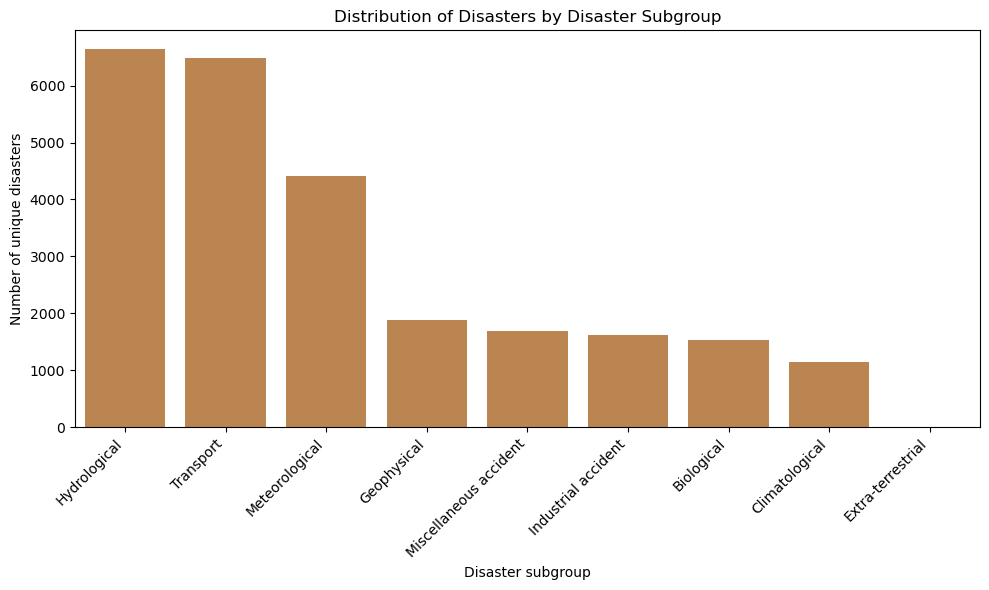

Top 3 disaster subgroups by number of disasters:


,Disaster Subgroup,Number of Disasters,Percentage (%)
0,Hydrological,6640,26.17
1,Transport,6482,25.55
2,Meteorological,4408,17.37


In [7]:
# Count unique disasters by disaster subgroup.
disaster_subgroup_counts = (
    df_clean.groupby("Disaster Subgroup")["Disaster_ID"]
    .nunique()
    .sort_values(ascending=False)
)

# Plot the distribution of unique disasters across disaster subgroups.
plt.figure(figsize=(10, 6))
sns.barplot(
    x=disaster_subgroup_counts.index,
    y=disaster_subgroup_counts.values,
    color="#CD853F"
 )
plt.title("Distribution of Disasters by Disaster Subgroup")
plt.xlabel("Disaster subgroup")
plt.ylabel("Number of unique disasters")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Show the top 3 disaster subgroups with their counts and percentages.
top3_subgroup = disaster_subgroup_counts.head(3)
top3_subgroup_summary = pd.DataFrame(
    {
        "Disaster Subgroup": top3_subgroup.index,
        "Number of Disasters": top3_subgroup.values,
        "Percentage (%)": (top3_subgroup / disaster_subgroup_counts.sum() * 100).round(2).values,
    }
)
print("Top 3 disaster subgroups by number of disasters:")
display(top3_subgroup_summary)

## Disaster Type

The chart below shows the distribution of unique disasters by **disaster type**.

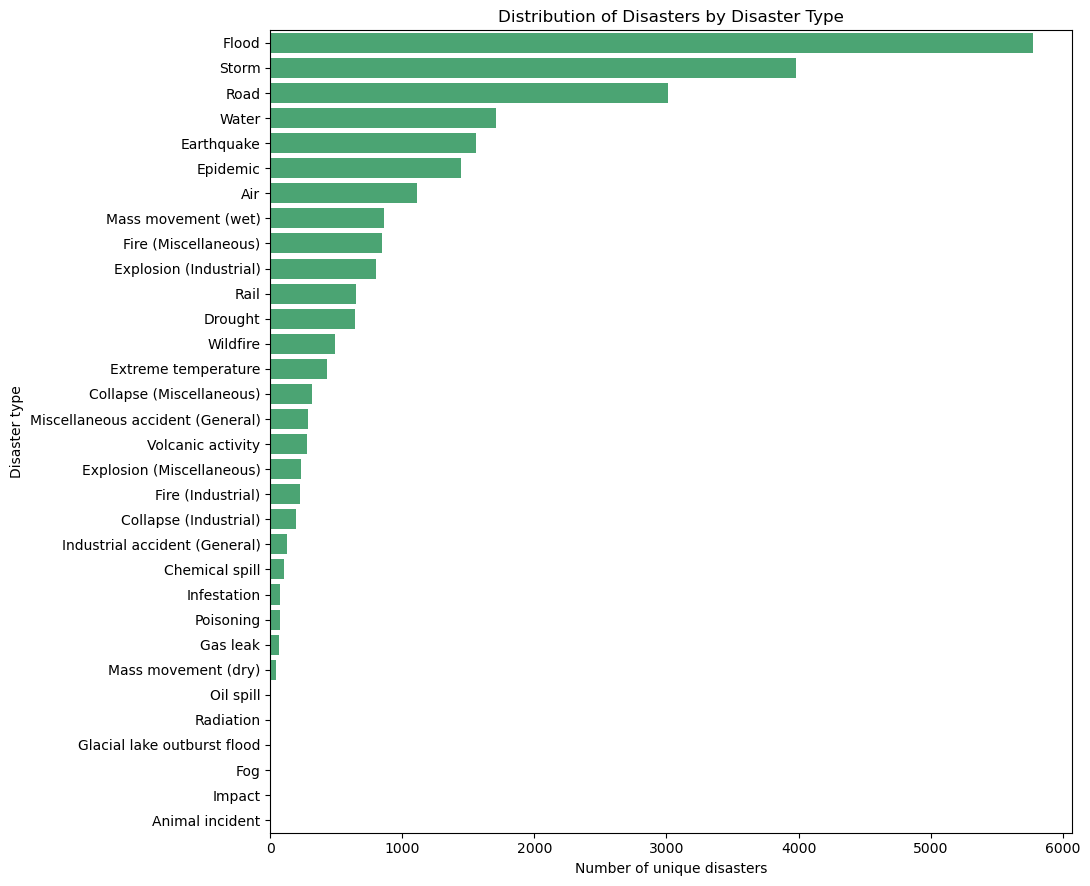

Top 3 disaster types by number of disasters:


,Disaster Type,Number of Disasters,Percentage (%)
0,Flood,5777,22.77
1,Storm,3979,15.68
2,Road,3011,11.87


In [8]:
# Count unique disasters by disaster type.
disaster_type_counts = (
    df_clean.groupby("Disaster Type")["Disaster_ID"]
    .nunique()
    .sort_values(ascending=False)
)

# Plot the distribution of unique disasters across disaster types.
plt.figure(figsize=(11, max(6, len(disaster_type_counts) * 0.28)))
sns.barplot(
    x=disaster_type_counts.values,
    y=disaster_type_counts.index,
    color="#3CB371"
 )
plt.title("Distribution of Disasters by Disaster Type")
plt.xlabel("Number of unique disasters")
plt.ylabel("Disaster type")
plt.tight_layout()
plt.show()

# Show the top 3 disaster types with their counts and percentages.
top3_type = disaster_type_counts.head(3)
top3_type_summary = pd.DataFrame(
    {
        "Disaster Type": top3_type.index,
        "Number of Disasters": top3_type.values,
        "Percentage (%)": (top3_type / disaster_type_counts.sum() * 100).round(2).values,
    }
)
print("Top 3 disaster types by number of disasters:")
display(top3_type_summary)

## Disaster Subtype

The chart below shows the distribution of unique disasters by **disaster subtype**.

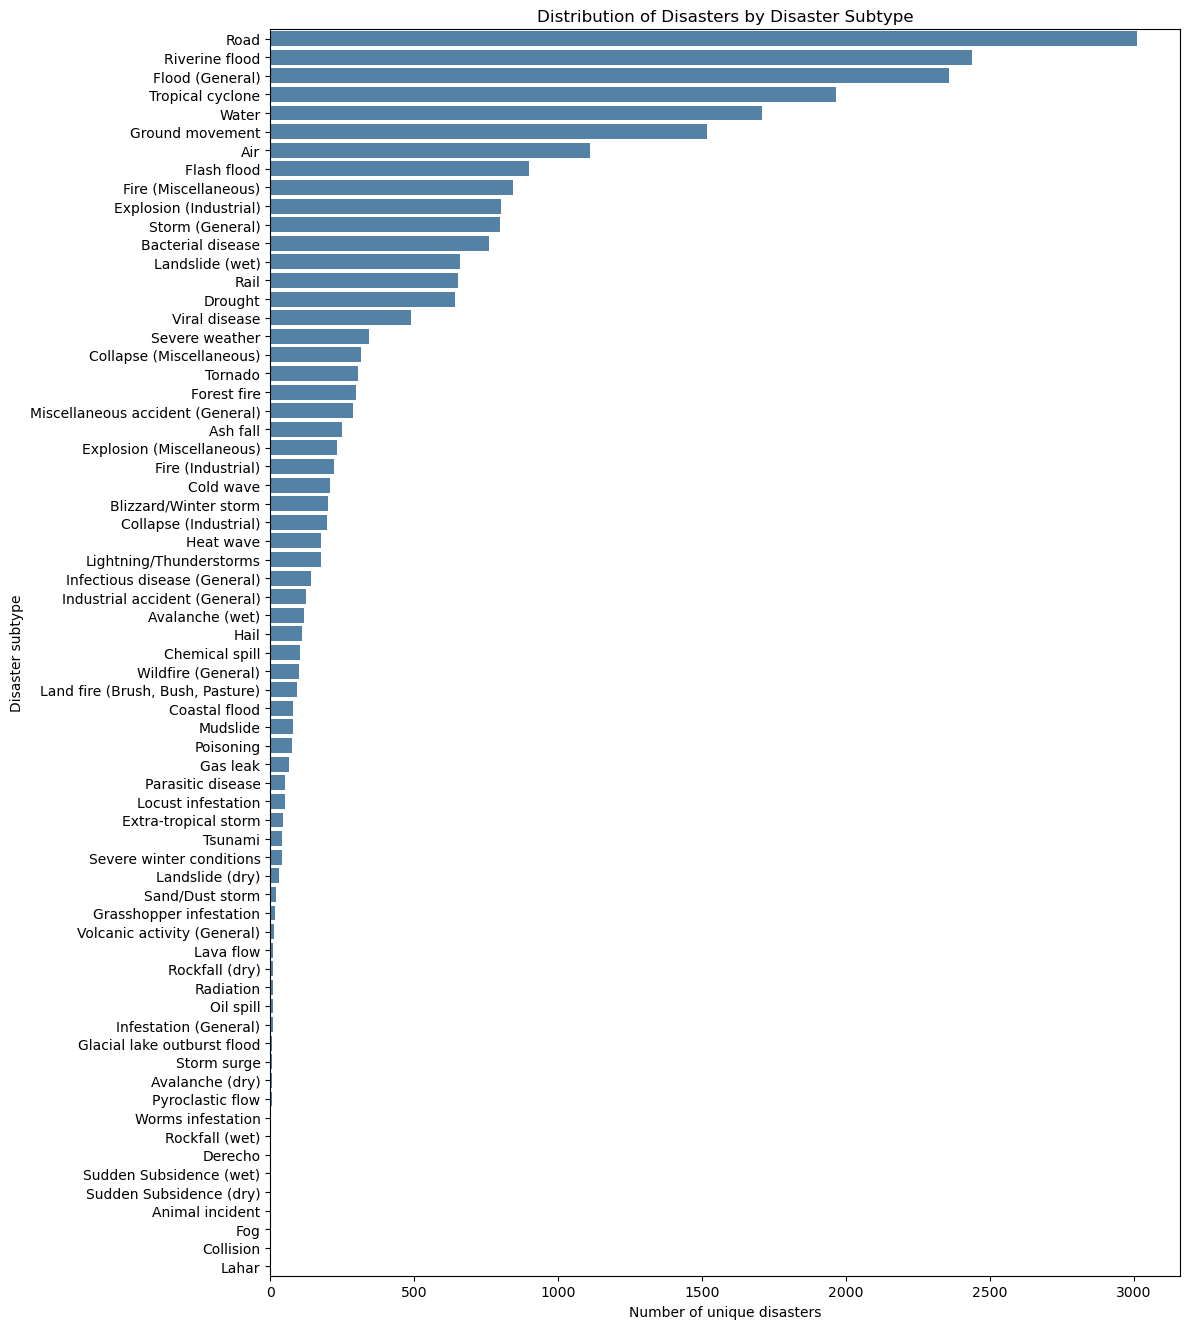

Top 3 disaster subtypes by number of disasters:


,Disaster Subtype,Number of Disasters,Percentage (%)
0,Road,3011,11.87
1,Riverine flood,2438,9.61
2,Flood (General),2358,9.29


In [9]:
# Count unique disasters by disaster subtype.
disaster_subtype_counts = (
    df_clean.groupby("Disaster Subtype")["Disaster_ID"]
    .nunique()
    .sort_values(ascending=False)
)

# Plot the distribution of unique disasters across disaster subtypes.
plt.figure(figsize=(12, max(6, len(disaster_subtype_counts) * 0.2)))
sns.barplot(
    x=disaster_subtype_counts.values,
    y=disaster_subtype_counts.index,
    color="#4682B4"
 )
plt.title("Distribution of Disasters by Disaster Subtype")
plt.xlabel("Number of unique disasters")
plt.ylabel("Disaster subtype")
plt.tight_layout()
plt.show()

# Show the top 3 disaster subtypes with their counts and percentages.
top3_subtype = disaster_subtype_counts.head(3)
top3_subtype_summary = pd.DataFrame(
    {
        "Disaster Subtype": top3_subtype.index,
        "Number of Disasters": top3_subtype.values,
        "Percentage (%)": (top3_subtype / disaster_subtype_counts.sum() * 100).round(2).values,
    }
)
print("Top 3 disaster subtypes by number of disasters:")
display(top3_subtype_summary)

## Disaster Region

This bar chart shows the distribution of disasters per **region** using unique `DisNo.` values. Because `DisNo.` is country-specific, the same disaster occurring in multiple countries within the same region is counted multiple times (one per country impact).

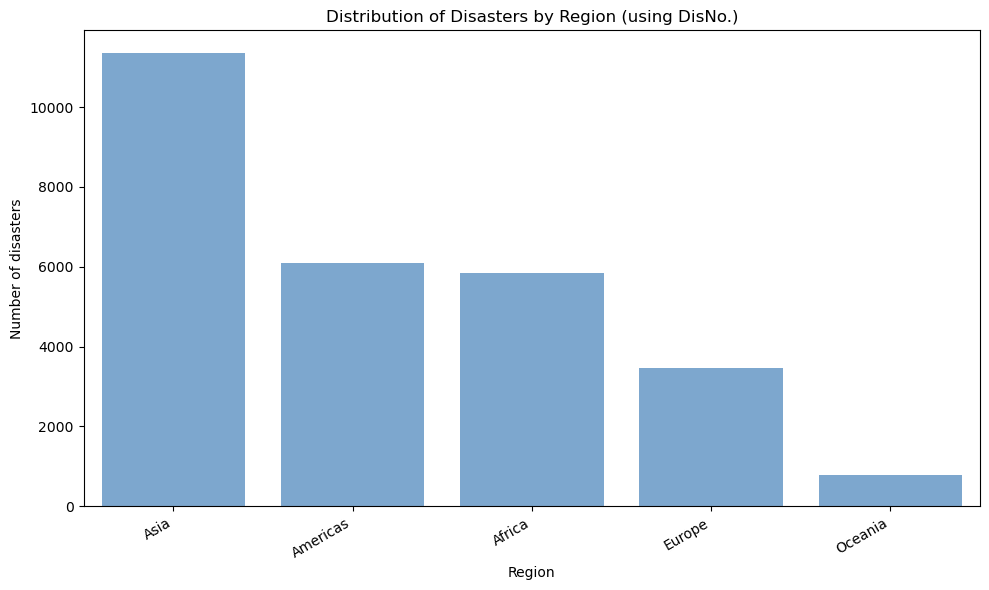

Top 3 regions by number of disasters:


,Region,Number of Disasters,Percentage (%)
0,Asia,11353,41.24
1,Americas,6094,22.13
2,Africa,5834,21.19


In [10]:
# Count disasters per region using DisNo. records.
disasters_per_region = (
    df_clean.groupby("Region")
    .size()
    .sort_values(ascending=False)
)

# Plot distribution of disasters by region.
plt.figure(figsize=(10, 6))
sns.barplot(
    x=disasters_per_region.index,
    y=disasters_per_region.values,
    color="#6FA8DC"
 )
plt.title("Distribution of Disasters by Region (using DisNo.)")
plt.xlabel("Region")
plt.ylabel("Number of disasters")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Show the top 3 regions with their counts and percentages.
top3_regions = disasters_per_region.head(3)
top3_regions_summary = pd.DataFrame(
    {
        "Region": top3_regions.index,
        "Number of Disasters": top3_regions.values,
        "Percentage (%)": (top3_regions / disasters_per_region.sum() * 100).round(2).values,
    }
)
print("Top 3 regions by number of disasters:")
display(top3_regions_summary)

## Disaster Total Deaths

This histogram shows the distribution of **Total Deaths** across disaster records. It helps visualize how concentrated events are at low versus high death counts.

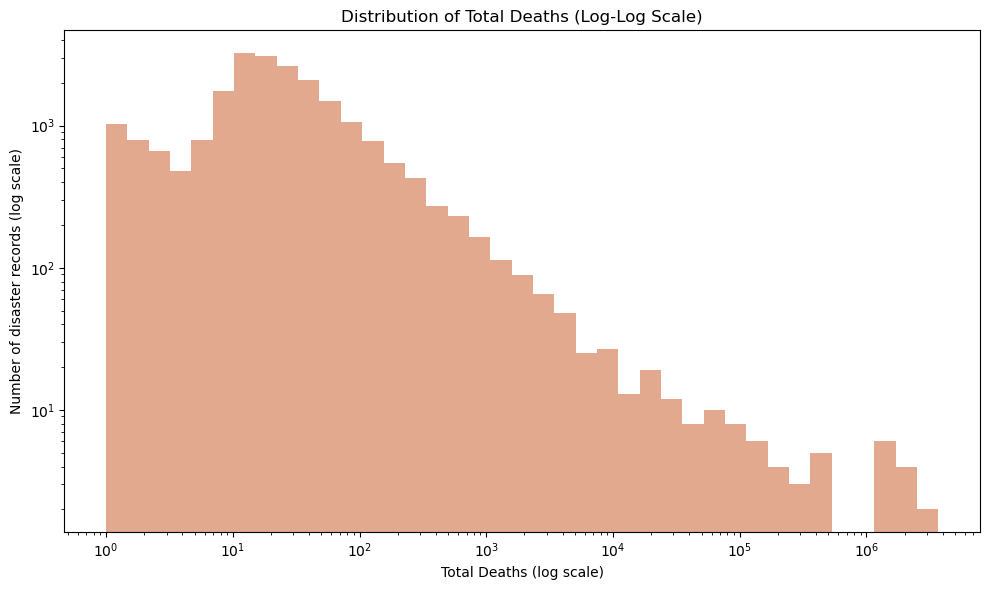

In [11]:
# Plot histogram of total deaths across disaster records on log-log scales.
total_deaths = df_clean["Total Deaths"].dropna()

# Use log-spaced bins
log_bins = np.logspace(
    np.log10(total_deaths.min()),
    np.log10(total_deaths.max()),
    40
)

plt.figure(figsize=(10, 6))
sns.histplot(total_deaths, bins=log_bins, color="#D98C6A", edgecolor="white")
plt.xscale("log")
plt.yscale("log")
plt.title("Distribution of Total Deaths (Log-Log Scale)")
plt.xlabel("Total Deaths (log scale)")
plt.ylabel("Number of disaster records (log scale)")
plt.tight_layout()
plt.show()

**Interpretation.** The log-log histogram indicates the the distribution of disaster deaths is right-skewed (heavy-tailed): most disaster records have relatively low death counts, while a small number of extreme events account for very high death totals. This suggests that rare high-impact disasters have a higher mortality risk. 

# 5. Relationships & Correlations

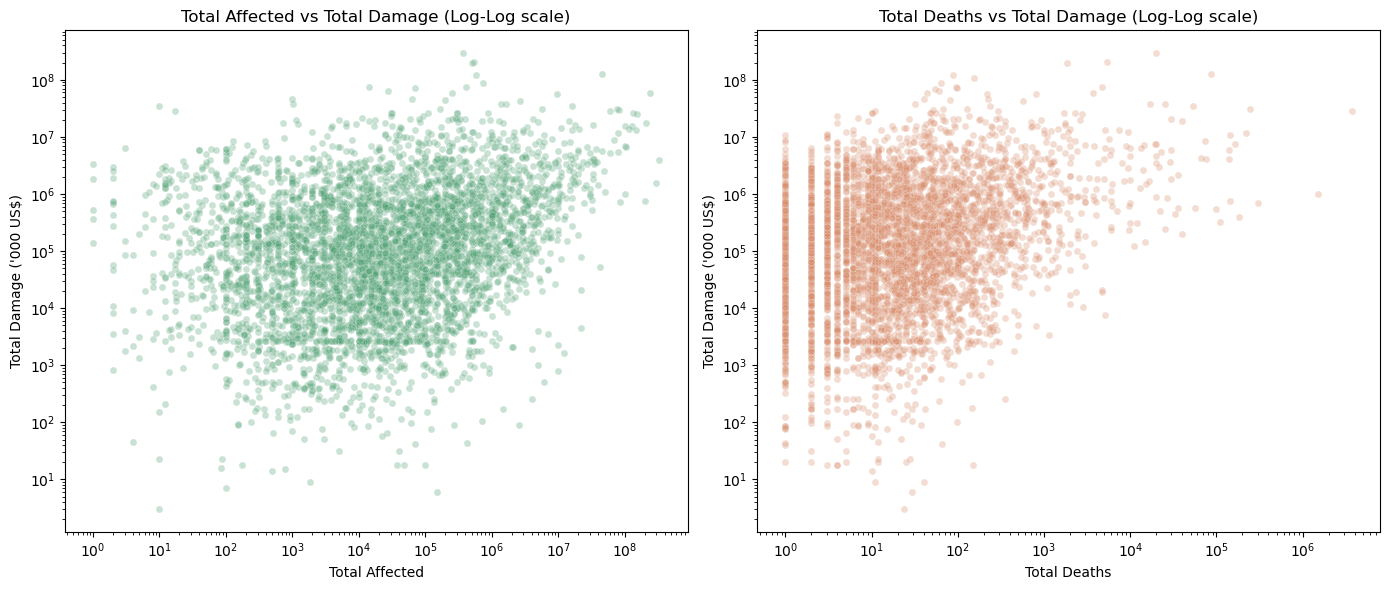

In [12]:
damage_col = "Total Damage, Adjusted ('000 US$)"
affected_col = "Total Affected"
deaths_col = "Total Deaths"

# Remove null values and keep strictly positive rows for log scales
affected_vs_damage = df_clean[[affected_col, damage_col]].dropna()
affected_vs_damage = affected_vs_damage[
    (affected_vs_damage[affected_col] > 0) & (affected_vs_damage[damage_col] > 0)
]

deaths_vs_damage = df_clean[[deaths_col, damage_col]].dropna()
deaths_vs_damage = deaths_vs_damage[
    (deaths_vs_damage[deaths_col] > 0) & (deaths_vs_damage[damage_col] > 0)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=affected_vs_damage,
    x=affected_col,
    y=damage_col,
    alpha=0.3,
    s=25,
    color="#4C9F70",
    ax=axes[0],
)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Total Affected vs Total Damage (Log-Log scale)")
axes[0].set_xlabel("Total Affected")
axes[0].set_ylabel("Total Damage ('000 US$)")

sns.scatterplot(
    data=deaths_vs_damage,
    x=deaths_col,
    y=damage_col,
    alpha=0.3,
    s=25,
    color="#D98C6A",
    ax=axes[1],
)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Total Deaths vs Total Damage (Log-Log scale)")
axes[1].set_xlabel("Total Deaths")
axes[1].set_ylabel("Total Damage ('000 US$)")

plt.tight_layout()
plt.show()

**Interpretation.** Both log-log scatter plots show a general positive association: larger human impact tends to be linked with higher economic damage. However, the spread is wide, meaning disasters with similar affected or death counts can still have very different total damages. 

# 6. Key Visualizations

## Time-based Plots

This section summarizes key **time-based trends** in the dataset: yearly disaster frequency, yearly total deaths, and yearly total damage.

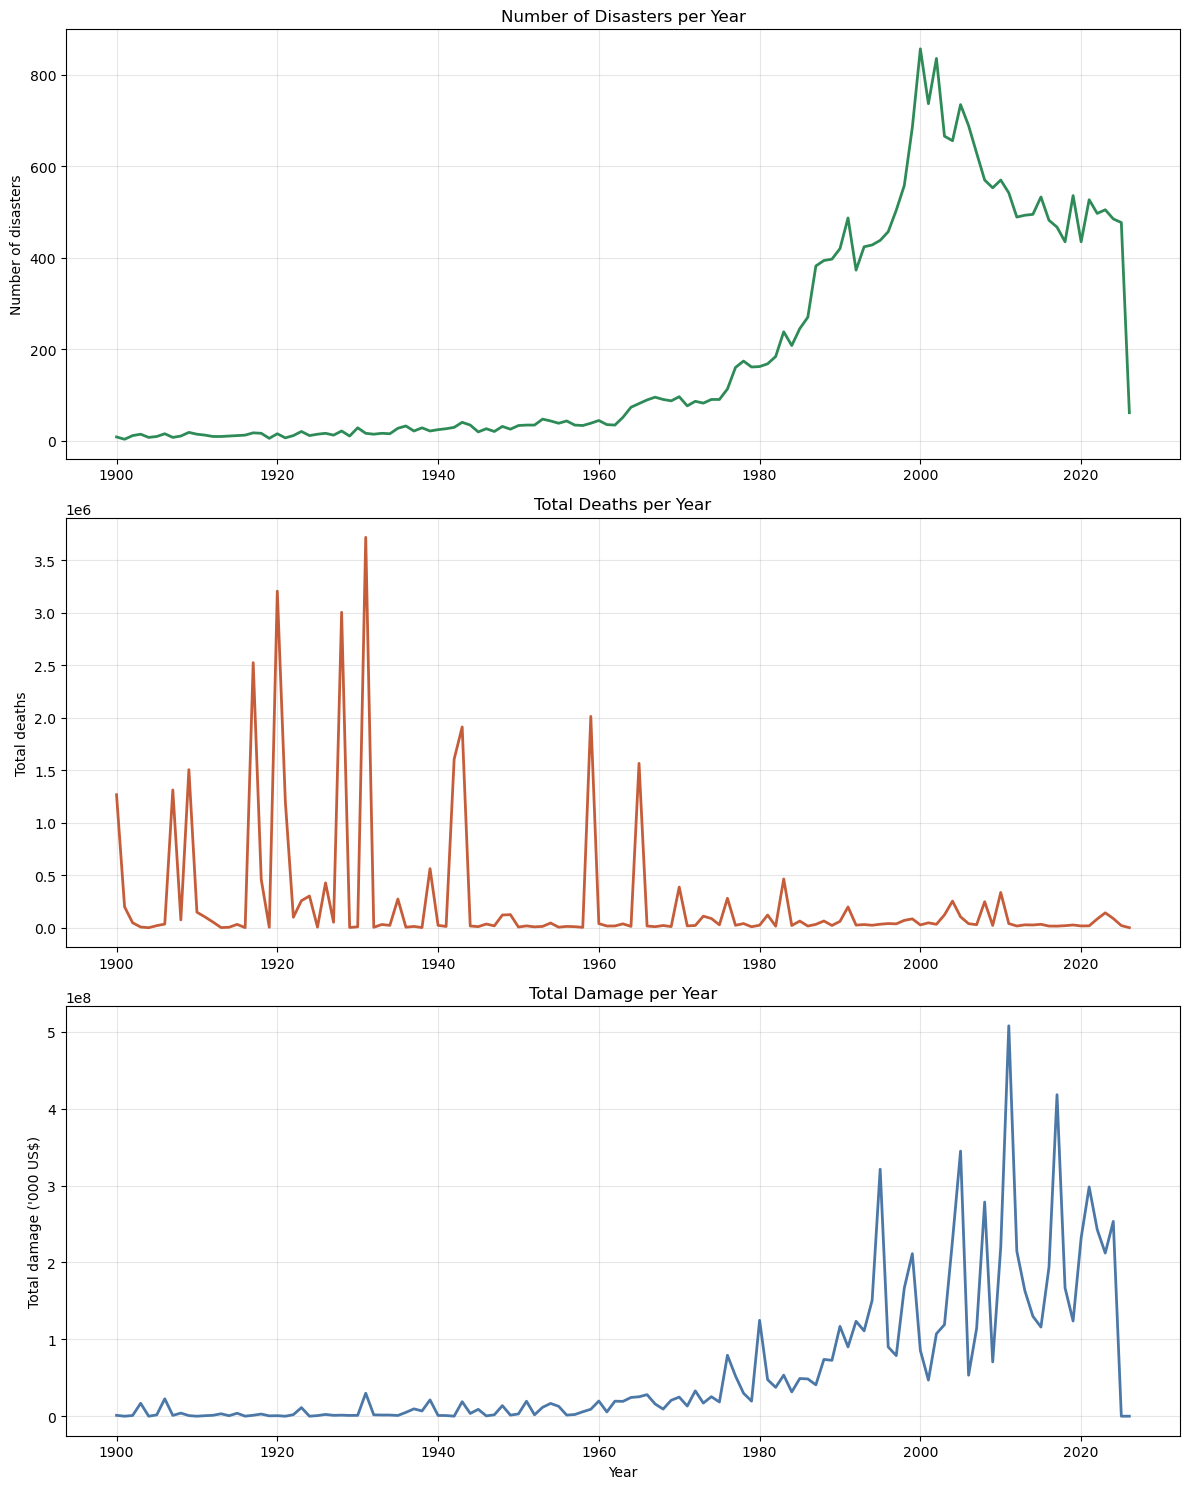

In [13]:
# Disaster count per year 
disasters_per_year = (
    df_clean.groupby("Start Year")["Disaster_ID"]
    .nunique()
    .sort_index()
)

# Total deaths per year
deaths_per_year = (
    df_clean.groupby("Start Year")["Total Deaths"]
    .sum()
    .sort_index()
)

# Total damage per year
damage_per_year = (
    df_clean.groupby("Start Year")["Total Damage, Adjusted ('000 US$)"]
    .sum()
    .sort_index()
)

fig, axes = plt.subplots(3, 1, figsize=(12, 15), sharex=False)

# Plot for disasters per year
axes[0].plot(disasters_per_year.index, disasters_per_year.values, color="#2E8B57", linewidth=2)
axes[0].set_title("Number of Disasters per Year")
axes[0].set_ylabel("Number of disasters")
axes[0].grid(alpha=0.3)

# Plot for deaths per year
axes[1].plot(deaths_per_year.index, deaths_per_year.values, color="#C65D3A", linewidth=2)
axes[1].set_title("Total Deaths per Year")
axes[1].set_ylabel("Total deaths")
axes[1].grid(alpha=0.3)

# Plot for damage per year
axes[2].plot(damage_per_year.index, damage_per_year.values, color="#4C78A8", linewidth=2)
axes[2].set_title("Total Damage per Year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Total damage ('000 US$)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Impact-based Plots

This plot shows **total deaths by disaster subgroup**, highlighting which subgroups contribute most to mortality. A small summary table reports the top 3 subgroups.

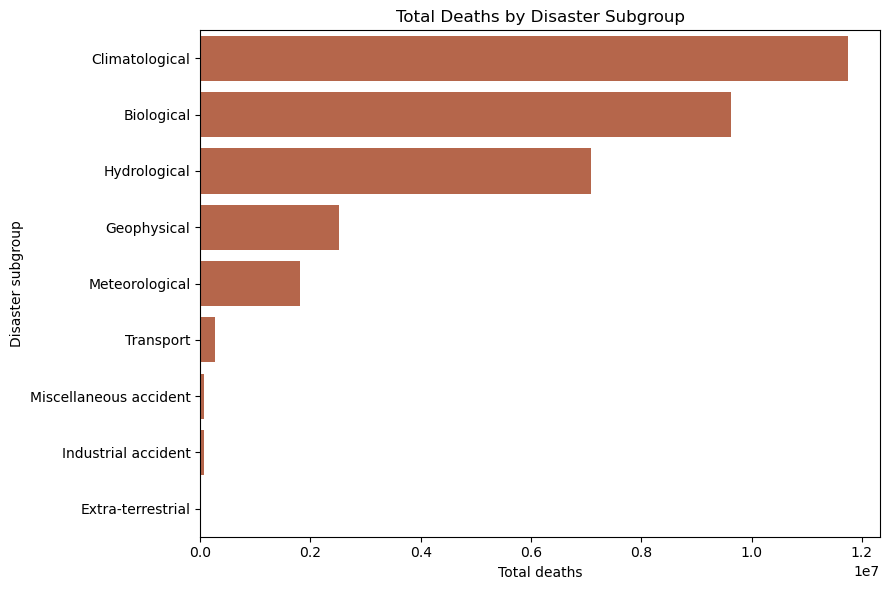

Top 3 disaster subgroups by total deaths:


,Disaster Subgroup,Total Deaths
0,Climatological,11740040.0
1,Biological,9629537.0
2,Hydrological,7095190.0


In [14]:
# Total deaths by disaster subgroup.
deaths_by_subgroup = (
    df_clean.groupby("Disaster Subgroup")["Total Deaths"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 6))
sns.barplot(
    x=deaths_by_subgroup.values,
    y=deaths_by_subgroup.index,
    color="#C65D3A"
 )
plt.title("Total Deaths by Disaster Subgroup")
plt.xlabel("Total deaths")
plt.ylabel("Disaster subgroup")
plt.tight_layout()
plt.show()

# Top 3 disaster subgroups by total deaths.
top3_deaths_subgroup = deaths_by_subgroup.head(3)
top3_deaths_subgroup_summary = pd.DataFrame(
    {
        "Disaster Subgroup": top3_deaths_subgroup.index,
        "Total Deaths": top3_deaths_subgroup.values,
    }
)
print("Top 3 disaster subgroups by total deaths:")
display(top3_deaths_subgroup_summary)

We now focus on the top 3 disaster subgroups and, for each of them, identify the top disaster types with the highest total deaths.

In [15]:
# For each top disaster subgroup, show up to 3 disaster types by total deaths (strictly positive totals).
top_subgroups = (
    df_clean.groupby("Disaster Subgroup")["Total Deaths"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
 )

for subgroup in top_subgroups:
    subgroup_type_totals = (
        df_clean[df_clean["Disaster Subgroup"] == subgroup]
        .groupby("Disaster Type")["Total Deaths"]
        .sum()
        .sort_values(ascending=False)
    )

    # Exclude zero-death totals
    subgroup_type_totals = subgroup_type_totals[subgroup_type_totals > 0]

    n_types = min(3, len(subgroup_type_totals))
    subgroup_top_types = subgroup_type_totals.head(n_types)

    summary = pd.DataFrame(
        {
            "Disaster Type": subgroup_top_types.index,
            "Total Deaths": subgroup_top_types.values,
        }
    )

    print(f"Top {n_types} disaster types in subgroup '{subgroup}' by total deaths:")
    display(summary)

Top 3 disaster types in subgroup 'Climatological' by total deaths:


,Disaster Type,Total Deaths
0,Drought,11734353.0
1,Wildfire,5209.0
2,Glacial lake outburst flood,478.0


Top 2 disaster types in subgroup 'Biological' by total deaths:


,Disaster Type,Total Deaths
0,Epidemic,9629525.0
1,Animal incident,12.0


Top 2 disaster types in subgroup 'Hydrological' by total deaths:


,Disaster Type,Total Deaths
0,Flood,7023421.0
1,Mass movement (wet),71769.0


## Geography-based Plots

This plot ranks the **top 10 countries by number of disasters** (count of records).

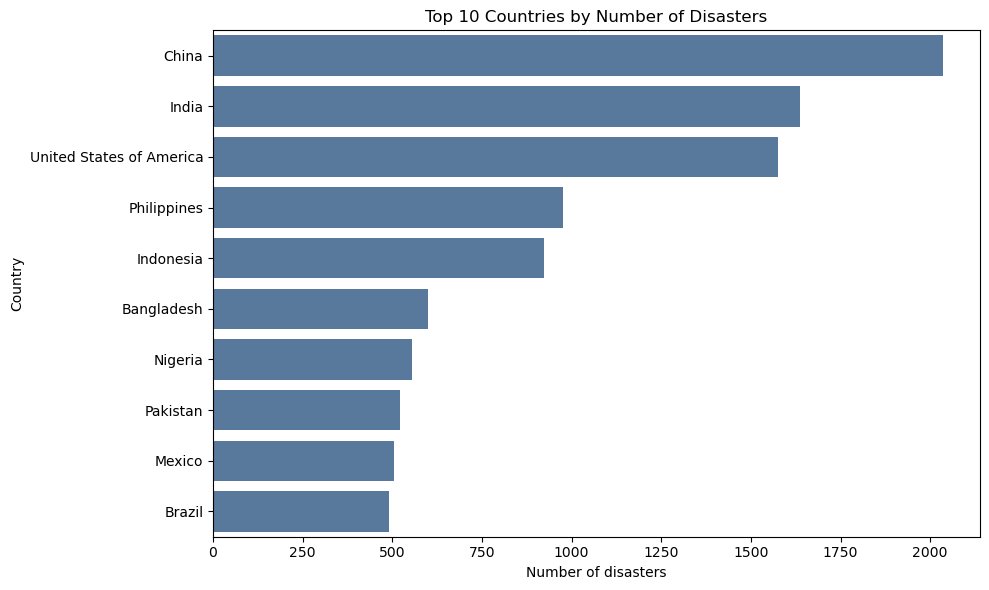

In [16]:
# Top 10 countries by number of disasters
top10_countries = (
    df_clean.groupby("Country")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top10_countries.values,
    y=top10_countries.index,
    color="#4C78A8"
 )
plt.title("Top 10 Countries by Number of Disasters")
plt.xlabel("Number of disasters")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

# 7. Insights & Conclusions



Across the EM-DAT records, we observed that the number of reported disasters increases over time. However, according to the documentation, this trend should be interpreted carefully. Part of this rise comes from better reporting, improved technology, and changes in data collection rather than a clear increase in actual disasters ([time bias](https://doc.emdat.be/docs/known-issues-and-limitations/specific-biases/)). Differences in reporting quality over time make it difficult to identify real long-term trends. For that reason, the documentation recommends excluding pre-2000 data from trend analyses based on EM-DAT.

Impacts are also very uneven. A small number of disaster types and countries account for a large share of deaths and damages. The data is strongly skewed, with a few extreme events dominating totals. This is partly because large disasters are more likely to be recorded than smaller ones ([threshold bias](https://doc.emdat.be/docs/known-issues-and-limitations/specific-biases/)).

In addition, some impacts, especially economic losses and indirect effects, are often missing or underreported. Data quality also varies across regions and hazard types ([accounting bias](https://doc.emdat.be/docs/known-issues-and-limitations/specific-biases/), [geographic bias](https://doc.emdat.be/docs/known-issues-and-limitations/specific-biases/)). For example, economic damages are reported less consistently than human impacts, and some regions have weaker coverage.